In [1]:
pip install python-dotenv

In [1]:
from dotenv import load_dotenv
import os
load_dotenv("config.env")

True

### OPEN AI Models

In [3]:
# !pip install openai

In [4]:
from openai import OpenAI

client = OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

### Responses API

In [3]:

response = client.responses.create(
    model="gpt-4.1-mini",
    instructions="You are a helpful assistant.",
    input="Hello!"
)
print(response.output_text)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************y6EA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

### Chat Completion API

In [4]:

completion = client.chat.completions.create(
  model="gpt-4.1-mini",
  messages=[
      {
          "role": "user",
          "content": "Write a one-sentence bedtime story about a unicorn."
      }
  ]
)

print(completion.choices[0].message.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************y6EA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [25]:
!pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.2/297.2 kB 10.7 MB/s eta 0:00:00


### Anthropic Claude

In [6]:
from anthropic import Anthropic

client = Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

message = client.messages.create(
    model="claude-sonnet-5",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Hello, Claude"}
    ]
)
print(message.content)

AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'API key is invalid.'}, 'request_id': None}

### Gemini

In [26]:
!pip install google-genai

In [6]:
from google import genai

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents="Explain how AI works in a few words",
)

print(response.text)

AI works by finding patterns in massive amounts of data to make predictions or decisions.


### Hugging Face Models

In [ ]:
# pip install --upgrade huggingface_hub

##### Text Generation

In [8]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)

completion = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?"
        }
    ],
)

print(completion.choices[0].message)

ChatCompletionOutputMessage(role='assistant', content='The capital of France is Paris.', reasoning=None, tool_call_id=None, tool_calls=None, reasoning_content=None, name=None)


##### Image Model

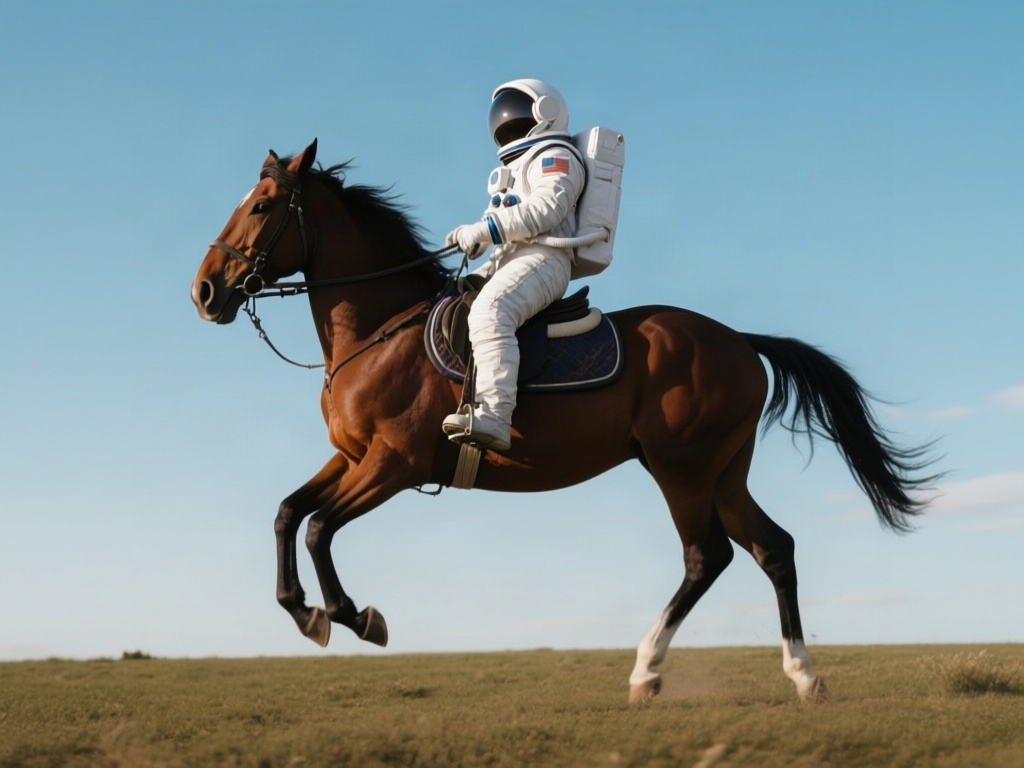

In [9]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "Astronaut riding a horse",
    model="Qwen/Qwen-Image",
)

image

### Using Groq API

In [ ]:
# !pip install groq

In [10]:
from groq import Groq

client = Groq()
completion = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[
      {
        "role": "user",
        "content": "How are you?"
      }
    ],
    temperature=1,
    max_completion_tokens=1024,
    top_p=1,
    stream=True,
    stop=None
)

for chunk in completion:
    print(chunk.choices[0].delta.content or "", end="")

GroqError: The api_key client option must be set either by passing api_key to the client or by setting the GROQ_API_KEY environment variable

In [11]:
from groq import Groq

client = Groq()
completion = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
      {
        "role": "user",
        "content": ""
      }
    ],
    temperature=1,
    max_completion_tokens=8192,
    top_p=1,
    reasoning_effort="medium",
    stream=True,
    stop=None
)

for chunk in completion:
    print(chunk.choices[0].delta.content or "", end="")

GroqError: The api_key client option must be set either by passing api_key to the client or by setting the GROQ_API_KEY environment variable